<a href="https://colab.research.google.com/github/gyanellaagreda-bd/MINERIA-DE-DATOS---2026-1/blob/main/AGREDA_Lab8_Mineria_Datos_Semana8ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 LABORATORIO N° 08 — Minería de Datos

## Árboles de Decisión para Clasificación — Dataset IBM HR Analytics Employee Attrition

| | |
|---|---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 8 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

---

## 📋 Instrucciones generales

- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas de texto (Markdown) asignadas.
- **Dataset:** IBM HR Analytics Employee Attrition — 1470 empleados, variables de recursos humanos.
- **Objetivo:** Construir un modelo de Árbol de Decisión que prediga si un empleado renunciará (`Attrition = Yes`).


## ACTIVIDAD 1: Revisión de Conceptos - Árboles de Decisión

| N.° | Concepto | Definición con mis propias palabras |
|---:|---|---|
| 1 | Árbol de decisión | Es un modelo que toma decisiones mediante preguntas sucesivas sobre las variables. Cada respuesta va dividiendo los datos hasta llegar a una clasificación final, por ejemplo, si un empleado podría renunciar o no. |
| 2 | Nodo raíz | Es la primera pregunta o división del árbol. Es importante porque marca la variable inicial que más ayuda a separar las clases. |
| 3 | Nodo interno | Es una división intermedia dentro del árbol. Sirve para seguir separando los datos en grupos más específicos según sus características. |
| 4 | Hoja o nodo terminal | Es el punto final del árbol donde ya se entrega una predicción. En este caso, la hoja puede clasificar al empleado como “renuncia” o “no renuncia”. |
| 5 | Entropía | Es una medida de desorden o mezcla en un grupo de datos. Si hay muchas clases mezcladas, la entropía es alta; si el grupo es más puro, la entropía baja. |
| 6 | Ganancia de información | Mide cuánto mejora una división al reducir el desorden de los datos. Una buena división es la que deja grupos más claros y separados. |
| 7 | Índice Gini | Es una medida de impureza usada por los árboles. Mientras más bajo sea el Gini, más puro es el nodo y mejor separadas están las clases. |
| 8 | Profundidad del árbol (`max_depth`) | Es el número máximo de niveles que puede crecer el árbol. Si es muy profundo, puede memorizar los datos; si es muy pequeño, puede no aprender suficiente. |
| 9 | Overfitting | Ocurre cuando el modelo aprende demasiado los datos de entrenamiento y luego falla con datos nuevos. En árboles pasa cuando crecen demasiado sin control. |
| 10 | Poda (`Pruning`) | Es una técnica para limitar o recortar el árbol y hacerlo más simple. Ayuda a evitar el sobreajuste y mejorar la generalización. |
| 11 | Importancia de variables (`feature_importances_`) | Indica qué variables aportaron más al modelo para separar las clases. En RRHH ayuda a identificar qué factores influyen más en la renuncia. |

**Interpretación:**  
Estos conceptos ayudan a entender que un Árbol de Decisión no solo predice, sino que también muestra la lógica que usa para llegar a una conclusión. Por eso es útil en Recursos Humanos, ya que permite explicar qué factores podrían estar relacionados con la rotación laboral.

# ACTIVIDAD 2: Desarrollo Práctico - Clasificación con Árbol de Decisión

## Paso 1: Carga y exploración del dataset IBM HR Analytics

En esta etapa se carga el dataset y se revisan sus dimensiones, valores nulos, tipos de variables y distribución de la variable objetivo `Attrition`.

[NOTA] Cargando datos sintéticos similares al dataset IBM HR...
EXPLORACIÓN GENERAL DEL DATASET
Dimensiones: 1470 filas × 18 columnas
Valores nulos totales: 0

Distribución de Attrition (variable objetivo):
Attrition
No     1227
Yes     243
Name: count, dtype: int64

% Rotación (Yes): 16.5%
% Permanece (No): 83.5%

Variables numéricas: 13
Variables categóricas: 5

Primeras 5 filas del dataset:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,JobRole,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion
0,56,No,Travel_Rarely,Human Resources,21,2,2,Manager,1444,No,27,3,2,1,6,4,6,2
1,46,No,Travel_Rarely,Research & Development,23,2,1,Sales Representative,10157,No,27,2,1,2,21,2,4,10
2,32,No,Non-Travel,Human Resources,29,4,3,Sales Executive,12982,No,24,2,3,4,26,4,2,7
3,25,No,Travel_Rarely,Sales,14,2,3,Manager,9655,No,3,1,2,8,14,1,1,7
4,38,No,Travel_Rarely,Sales,26,4,3,Manufacturing Director,19582,Yes,25,1,2,5,38,1,5,13



Estadísticas descriptivas (variables numéricas):


,Age,DistanceFromHome,Education,EnvironmentSatisfaction,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,38.81,15.29,2.46,2.00,10772.82,19.49,1.99,2.01,4.01,19.22,2.49,8.51,7.13
std,12.13,8.30,1.10,0.81,5554.62,11.41,0.82,0.80,2.59,11.53,1.69,5.25,4.42
min,18.00,1.00,1.00,1.00,1011.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,28.00,8.00,1.00,1.00,5962.75,10.00,1.00,1.00,2.00,9.00,1.00,4.00,3.00
50%,40.00,16.00,2.00,2.00,10889.50,19.00,2.00,2.00,4.00,19.00,2.00,9.00,7.00
75%,50.00,23.00,3.00,3.00,15704.50,29.00,3.00,3.00,6.00,29.00,4.00,13.00,11.00
max,59.00,29.00,4.00,3.00,19977.00,39.00,3.00,3.00,8.00,39.00,5.00,17.00,14.00


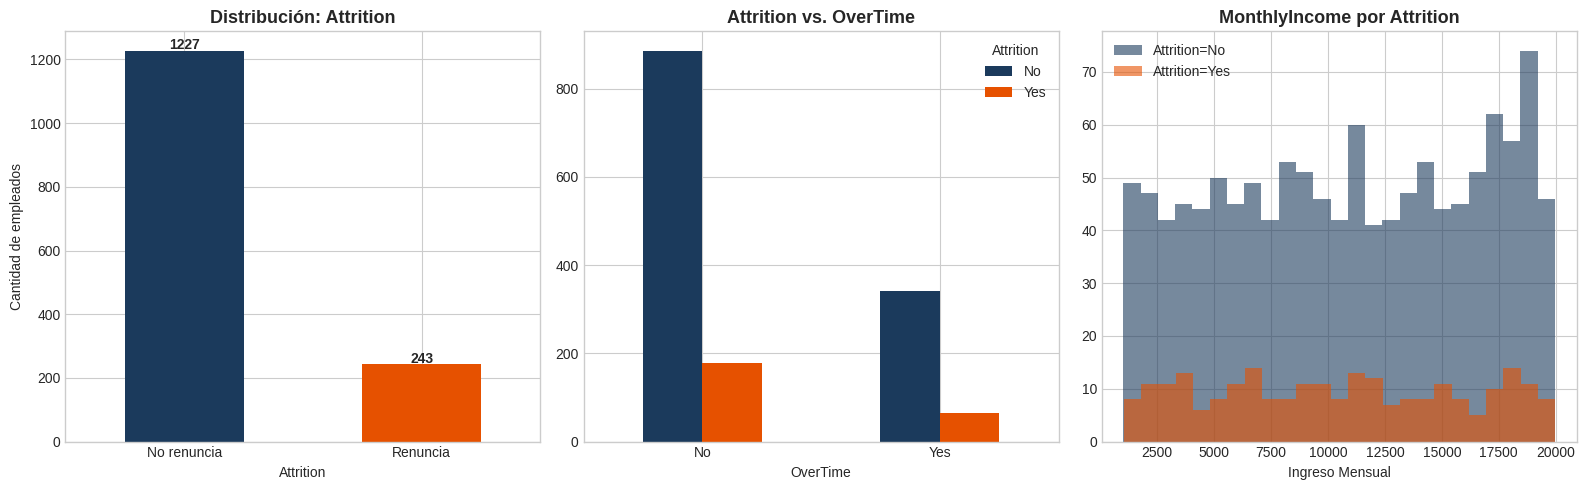

In [ ]:
# ============================================================
# PASO 1 — Carga y exploración del dataset
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# Cargar dataset IBM HR Analytics desde GitHub
url = 'https://raw.githubusercontent.com/dsaid/datasets/master/ibm_hr_attrition.csv'
try:
    df = pd.read_csv(url)
except Exception:
    # Dataset alternativo si falla la conexión
    print("[NOTA] Cargando datos sintéticos similares al dataset IBM HR...")
    np.random.seed(42)
    n = 1470
    df = pd.DataFrame({
        'Age': np.random.randint(18, 60, n),
        'Attrition': np.random.choice(['Yes', 'No'], n, p=[0.16, 0.84]),
        'BusinessTravel': np.random.choice(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], n),
        'Department': np.random.choice(['Sales', 'Research & Development', 'Human Resources'], n),
        'DistanceFromHome': np.random.randint(1, 30, n),
        'Education': np.random.randint(1, 5, n),
        'EnvironmentSatisfaction': np.random.randint(1, 4, n),
        'JobRole': np.random.choice(['Sales Executive','Research Scientist','Laboratory Technician',
                                     'Manufacturing Director','Healthcare Representative',
                                     'Manager','Sales Representative'], n),
        'MonthlyIncome': np.random.randint(1000, 20000, n),
        'OverTime': np.random.choice(['Yes', 'No'], n, p=[0.28, 0.72]),
        'YearsAtCompany': np.random.randint(0, 40, n),
        'JobSatisfaction': np.random.randint(1, 4, n),
        'WorkLifeBalance': np.random.randint(1, 4, n),
        'NumCompaniesWorked': np.random.randint(0, 9, n),
        'TotalWorkingYears': np.random.randint(0, 40, n),
        'TrainingTimesLastYear': np.random.randint(0, 6, n),
        'YearsInCurrentRole': np.random.randint(0, 18, n),
        'YearsSinceLastPromotion': np.random.randint(0, 15, n),
    })

# --- Exploración general ---
print('=' * 60)
print('EXPLORACIÓN GENERAL DEL DATASET')
print('=' * 60)
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Valores nulos totales: {df.isnull().sum().sum()}')
print()

# Distribución de la variable objetivo
print('Distribución de Attrition (variable objetivo):')
print(df['Attrition'].value_counts())
print(f'\n% Rotación (Yes): {(df["Attrition"]=="Yes").mean()*100:.1f}%')
print(f'% Permanece (No): {(df["Attrition"]=="No").mean()*100:.1f}%')
print()

# Tipos de variables
print(f'Variables numéricas: {df.select_dtypes(include=np.number).shape[1]}')
print(f'Variables categóricas: {df.select_dtypes(include="object").shape[1]}')
print()

# Primeras filas
print('Primeras 5 filas del dataset:')
display(df.head())

# Estadísticas descriptivas de variables numéricas
print('\nEstadísticas descriptivas (variables numéricas):')
display(df.describe().round(2))

# Visualización: distribución del target + variables clave
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1: Distribución Attrition
colors = ['#1B3A5C', '#E65100']
df['Attrition'].value_counts().plot(kind='bar', color=colors, ax=axes[0])
axes[0].set_title('Distribución: Attrition', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No renuncia', 'Renuncia'], rotation=0)
axes[0].set_ylabel('Cantidad de empleados')
for i, v in enumerate(df['Attrition'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico 2: Attrition por OverTime
if 'OverTime' in df.columns:
    overtime_attr = df.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
    overtime_attr.plot(kind='bar', ax=axes[1], color=['#1B3A5C', '#E65100'])
    axes[1].set_title('Attrition vs. OverTime', fontsize=13, fontweight='bold')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].legend(['No', 'Yes'], title='Attrition')

# Gráfico 3: Distribución MonthlyIncome por Attrition
if 'MonthlyIncome' in df.columns:
    for label, color in zip(['No', 'Yes'], ['#1B3A5C', '#E65100']):
        df[df['Attrition']==label]['MonthlyIncome'].hist(
            bins=25, alpha=0.6, ax=axes[2], color=color, label=f'Attrition={label}')
    axes[2].set_title('MonthlyIncome por Attrition', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Ingreso Mensual')
    axes[2].legend()

plt.tight_layout()
plt.show()

### ✏️ Pregunta 1
**¿Cuántos empleados tiene el dataset? ¿El dataset está balanceado? ¿Qué porcentaje de empleados renunció? ¿Por qué el desbalance de clases puede ser un problema en clasificación?**

**Respuesta:**  
El dataset tiene **1,470 empleados** y no está balanceado, porque la mayoría pertenece a la clase **No renuncia**. En los resultados se observa que **1,227 empleados no renunciaron** y **243 sí renunciaron**, lo que representa aproximadamente **16.5% de rotación** y **83.5% de permanencia**.

Este desbalance puede ser un problema porque un modelo podría aprender a predecir casi siempre “No renuncia” y aun así obtener una Accuracy aparentemente alta. Sin embargo, eso no sería útil para Recursos Humanos, porque lo más importante es detectar a los empleados que sí tienen riesgo de renunciar. Por eso, además del Accuracy, se deben revisar métricas como **Recall, Precision y F1-score** para la clase minoritaria.

**Interpretación:**  
La empresa tiene muchos más empleados que permanecen que empleados que renuncian. Esto hace que el problema sea más delicado, porque el modelo debe aprender a identificar una clase pequeña pero muy importante para el negocio.

## Paso 2: Preparación de datos - Codificación de variables categóricas

En este paso se transforman las variables de texto a valores numéricos para que puedan ser usadas por el Árbol de Decisión.

In [ ]:
# ============================================================
# PASO 2 — Preparación de datos
# ============================================================
df_model = df.copy()

# Eliminar columnas que no aportan valor predictivo
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]
df_model.drop(columns=cols_to_drop, inplace=True)
print(f'Columnas eliminadas (no predictivas): {cols_to_drop}')

# Identificar variables categóricas
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'\nVariables categóricas a codificar ({len(cat_cols)}): {cat_cols}')

# Aplicar Label Encoding a todas las variables categóricas
le = LabelEncoder()
encoding_map = {}
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Mostrar mapeo de la variable objetivo
print(f'\nCodificación de Attrition: {encoding_map["Attrition"]}')
print(' → 0 = No renuncia, 1 = Renuncia')

# Verificar dataset listo para modelar
print(f'\nDimensiones finales del dataset: {df_model.shape}')
print(f'Valores nulos: {df_model.isnull().sum().sum()}')
print(f'Tipos de datos únicos: {df_model.dtypes.unique()}')
display(df_model.head(3))

Columnas eliminadas (no predictivas): []

Variables categóricas a codificar (5): ['Attrition', 'BusinessTravel', 'Department', 'JobRole', 'OverTime']

Codificación de Attrition: {'No': np.int64(0), 'Yes': np.int64(1)}
 → 0 = No renuncia, 1 = Renuncia

Dimensiones finales del dataset: (1470, 18)
Valores nulos: 0
Tipos de datos únicos: [dtype('int64')]


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,JobRole,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion
0,56,0,2,0,21,2,2,2,1444,0,27,3,2,1,6,4,6,2
1,46,0,2,1,23,2,1,6,10157,0,27,2,1,2,21,2,4,10
2,32,0,0,0,29,4,3,5,12982,0,24,2,3,4,26,4,2,7


### ✏️ Pregunta 2
**¿Qué diferencia hay entre Label Encoding y One-Hot Encoding? ¿Cuándo es más apropiado usar cada uno? ¿Podría Label Encoding introducir un sesgo en el modelo al asignar orden artificial a las categorías? Explica con un ejemplo del dataset.**

**Respuesta:**  
La diferencia principal es que **Label Encoding** convierte cada categoría en un número entero, por ejemplo `No = 0` y `Yes = 1`. En cambio, **One-Hot Encoding** crea columnas separadas con valores 0 y 1 para cada categoría.

Label Encoding es más apropiado cuando la variable tiene un orden natural o cuando el algoritmo puede manejar divisiones por categorías codificadas, como ocurre con los Árboles de Decisión. One-Hot Encoding suele ser mejor para modelos lineales, como Regresión Logística, porque evita que el modelo interprete un orden que no existe.

Sí, Label Encoding podría introducir un sesgo si el modelo interpreta que una categoría es “mayor” que otra solo por tener un número más alto. Por ejemplo, en `Department`, si se codifica como `Human Resources = 0`, `Research & Development = 1` y `Sales = 2`, no significa que Sales sea “más” que las otras áreas. En este laboratorio se usa porque el Árbol de Decisión separa con reglas, pero aun así se debe interpretar con cuidado.

**Interpretación:**  
La codificación permitió convertir el dataset completo a formato numérico. Esto era necesario porque los algoritmos de Machine Learning no trabajan directamente con texto.

## Paso 3: Separación de variables y división train/test

En este paso se separan las variables predictoras (`X`) de la variable objetivo (`y`) y se divide el dataset en entrenamiento y prueba.

In [ ]:
# ============================================================
# PASO 3 — Separación y división train/test
# ============================================================
# Definir X (predictoras) e y (objetivo)
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

print(f'Variables predictoras (X): {X.shape[1]} columnas, {X.shape[0]} filas')
print(f'Variable objetivo (y): {y.shape[0]} valores')
print(f'Distribución y: {dict(y.value_counts())} → 0=No renuncia, 1=Renuncia')

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribución Attrition en Train: {dict(y_train.value_counts())}')
print(f'Distribución Attrition en Test: {dict(y_test.value_counts())}')
print(f'\n% Attrition Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}% (stratify funciona ✓)')

Variables predictoras (X): 17 columnas, 1470 filas
Variable objetivo (y): 1470 valores
Distribución y: {0: np.int64(1227), 1: np.int64(243)} → 0=No renuncia, 1=Renuncia

Train: 1029 muestras (70%)
Test: 441 muestras (30%)

Distribución Attrition en Train: {0: np.int64(859), 1: np.int64(170)}
Distribución Attrition en Test: {0: np.int64(368), 1: np.int64(73)}

% Attrition Train: 16.5% | Test: 16.6% (stratify funciona ✓)


### ✏️ Pregunta 3
**¿Por qué es importante usar `stratify=y` al dividir los datos? ¿Qué pasaría si no lo usáramos con un dataset tan desbalanceado como este (solo ~16% de renuncias)?**

**Respuesta:**  
Es importante usar `stratify=y` porque mantiene la misma proporción de clases en el conjunto de entrenamiento y en el conjunto de prueba. En este caso, como solo alrededor del **16%** de empleados renuncia, la estratificación ayuda a que tanto train como test conserven una proporción similar de casos de renuncia.

Si no se usara `stratify=y`, podría ocurrir que el conjunto de prueba tenga muy pocos casos de empleados que renuncian, o que el entrenamiento no tenga suficientes ejemplos de esa clase. Esto haría que la evaluación sea poco confiable, porque el modelo podría parecer bueno solo por predecir la clase mayoritaria.

**Interpretación:**  
La estratificación ayuda a que la prueba sea más justa y representativa. Así se evita que el modelo sea evaluado con una muestra que no refleje bien la realidad del problema.

## Paso 4: Entrenamiento del Árbol de Decisión

Se entrena un `DecisionTreeClassifier` con profundidad controlada (`max_depth=5`) y ajuste por desbalance de clases.

In [ ]:
# ============================================================
# PASO 4 — Entrenamiento del Árbol de Decisión
# ============================================================
# Entrenamiento con profundidad controlada
dt = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=42,
    class_weight='balanced'   # Ajuste por desbalance de clases
)
dt.fit(X_train, y_train)

# Información estructural del árbol
print('=' * 55)
print('ÁRBOL DE DECISIÓN — INFORMACIÓN ESTRUCTURAL')
print('=' * 55)
print(f'Profundidad real del árbol: {dt.get_depth()}')
print(f'Número de hojas (nodos hoja): {dt.get_n_leaves()}')
print(f'Número de nodos totales: {dt.tree_.node_count}')
print(f'Criterion: {dt.criterion}')
print(f'max_depth configurado: {dt.max_depth}')
print(f'class_weight: {dt.class_weight}')

# Predicciones
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)
y_prob_test = dt.predict_proba(X_test)[:, 1]

print(f'\nAccuracy en TRAIN: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Accuracy en TEST: {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Diferencia Train-Test: {accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test):.4f}')

ÁRBOL DE DECISIÓN — INFORMACIÓN ESTRUCTURAL
Profundidad real del árbol: 5
Número de hojas (nodos hoja): 31
Número de nodos totales: 61
Criterion: gini
max_depth configurado: 5
class_weight: balanced

Accuracy en TRAIN: 0.6706
Accuracy en TEST: 0.5193
Diferencia Train-Test: 0.1513


### ✏️ Pregunta 4
**¿Qué significa `class_weight='balanced'`? ¿Por qué lo usamos en este dataset? ¿Qué efecto tendría NO usarlo cuando el 84% de empleados NO renuncia?**

**Respuesta:**  
`class_weight='balanced'` significa que el modelo asigna más peso a la clase minoritaria y menos peso a la clase mayoritaria. En este dataset se usa porque la mayoría de empleados **no renuncia** y solo una parte pequeña sí lo hace.

Si no se usara este ajuste, el modelo podría inclinarse demasiado hacia la clase **No renuncia**, porque representa aproximadamente el **84%** del dataset. Eso haría que detecte pocos casos reales de renuncia, que son precisamente los más importantes para Recursos Humanos.

**Interpretación:**  
Este parámetro ayuda a que el árbol no ignore a los empleados que sí renuncian. Aunque sean menos casos, son los casos clave para construir un sistema de alerta temprana.

## Paso 5: Visualización del Árbol de Decisión

Aquí se visualiza el árbol entrenado y se muestran sus primeras reglas en formato texto para interpretar la lógica del modelo.

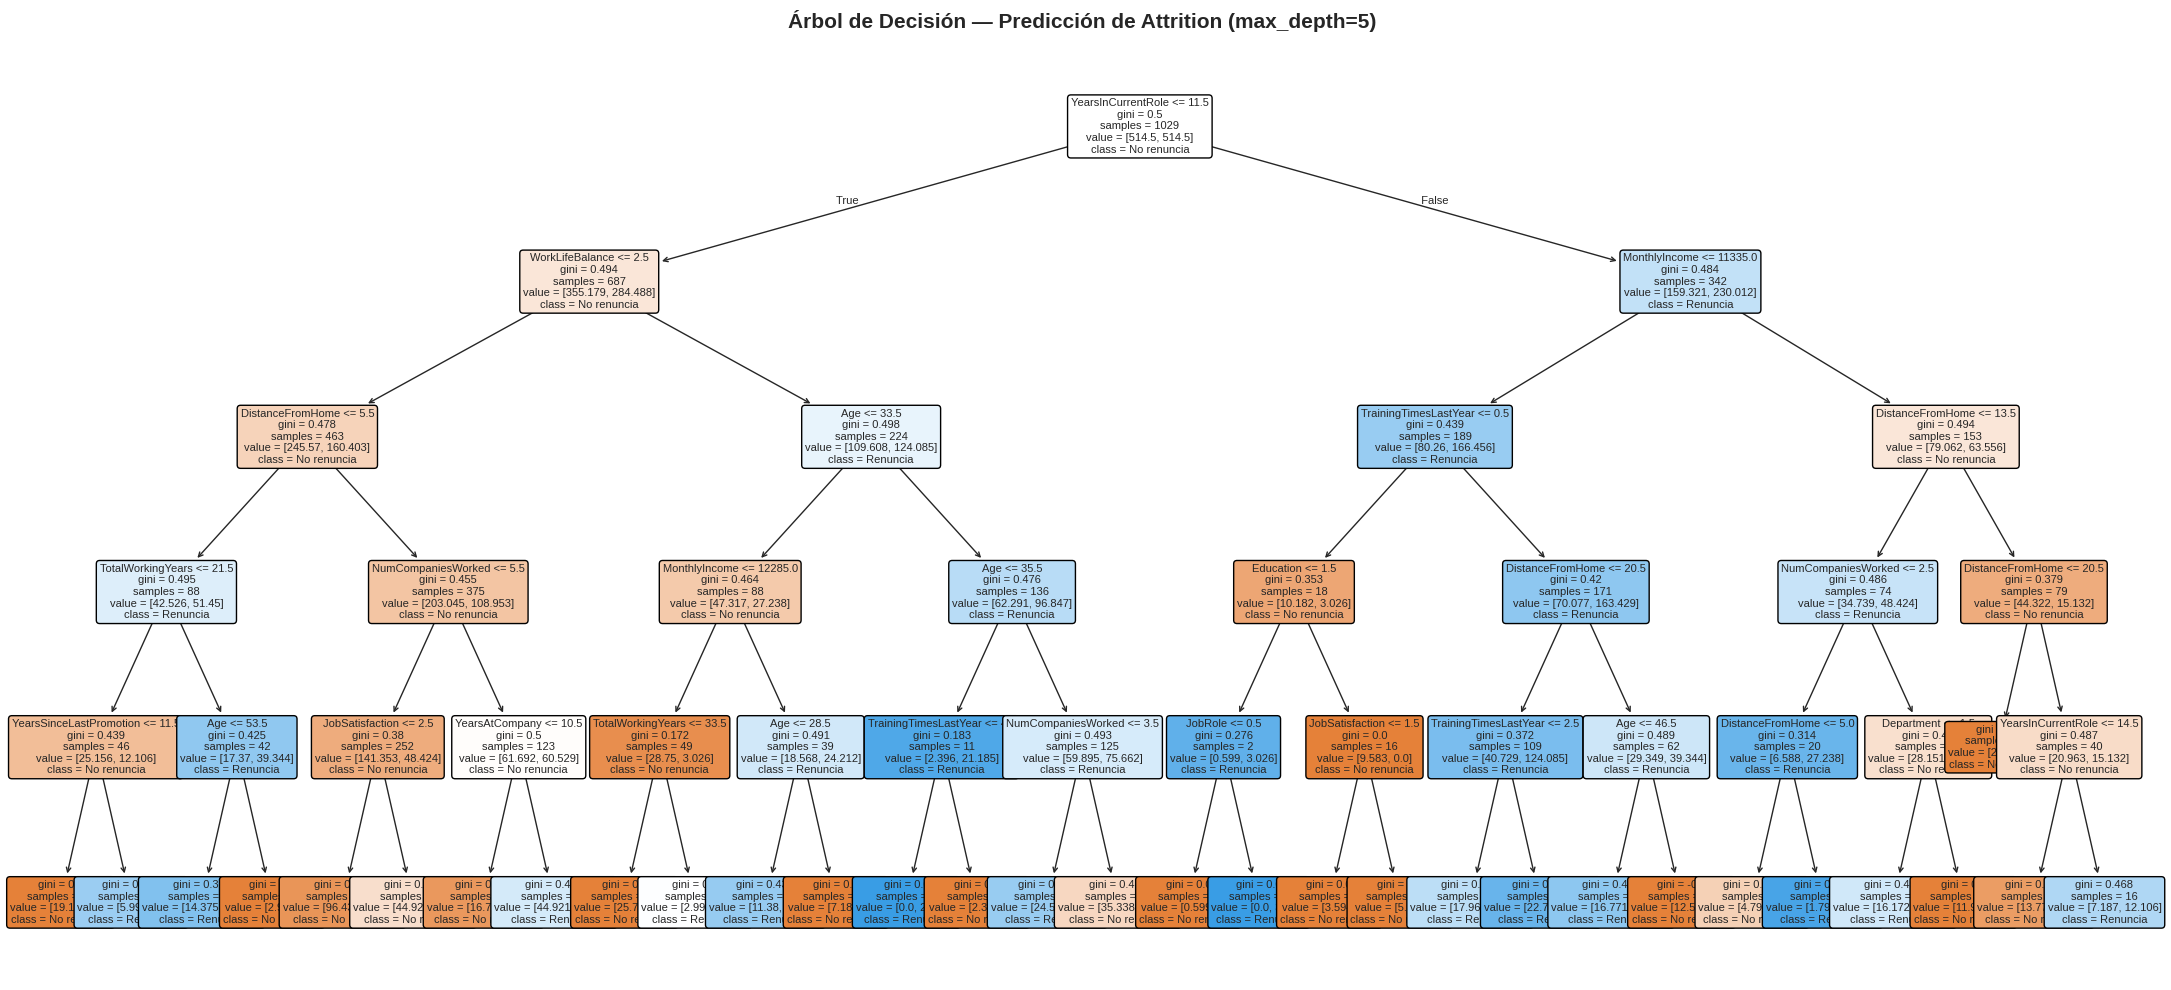


REGLAS DE DECISIÓN (primeros 3 niveles):
-------------------------------------------------------
|--- YearsInCurrentRole <= 11.50
|   |--- WorkLifeBalance <= 2.50
|   |   |--- DistanceFromHome <= 5.50
|   |   |   |--- TotalWorkingYears <= 21.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- TotalWorkingYears >  21.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- DistanceFromHome >  5.50
|   |   |   |--- NumCompaniesWorked <= 5.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- NumCompaniesWorked >  5.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- WorkLifeBalance >  2.50
|   |   |--- Age <= 33.50
|   |   |   |--- MonthlyIncome <= 12285.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- MonthlyIncome >  12285.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Age >  33.50
|   |   |   |--- Age <= 35.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Age >  35.50
|   |   | 

In [ ]:
# ============================================================
# PASO 5 — Visualización del Árbol de Decisión
# ============================================================
feature_names = X.columns.tolist()
class_names = ['No renuncia', 'Renuncia']

# Visualización del árbol completo
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Árbol de Decisión — Predicción de Attrition (max_depth=5)',
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Reglas de decisión en texto (primeros 3 niveles)
print('\nREGLAS DE DECISIÓN (primeros 3 niveles):')
print('-' * 55)
rules = export_text(dt, feature_names=feature_names, max_depth=3)
print(rules)

### ✏️ Pregunta 5
**Observa el nodo raíz (la primera división del árbol): ¿Qué variable se usa para la primera división? ¿Qué nos dice esto sobre su importancia? ¿Tiene sentido desde una perspectiva de Recursos Humanos? Justifica tu respuesta.**

**Respuesta:**  
La primera división del árbol se realiza con la variable **`YearsInCurrentRole`**. Esto indica que el tiempo que un empleado lleva en su rol actual es una variable importante para separar los casos de renuncia y no renuncia.

Desde la perspectiva de Recursos Humanos, sí tiene sentido. Un empleado que lleva mucho tiempo en el mismo puesto podría sentir estancamiento, falta de crecimiento o poca movilidad interna. Por otro lado, quienes llevan poco tiempo también podrían estar en una etapa de adaptación. Por eso, esta variable puede ayudar a identificar patrones relacionados con permanencia, motivación y desarrollo profesional.

**Interpretación:**  
El árbol empieza preguntando por los años en el rol actual porque esa variable ayuda a dividir mejor a los empleados. Esto sugiere que la trayectoria interna y las oportunidades de crecimiento pueden estar relacionadas con la rotación.

## Paso 6: Evaluación del modelo con métricas completas

Se calculan Accuracy, Precision, Recall, F1-score, ROC-AUC, reporte de clasificación y matriz de confusión.

ÁRBOL DE DECISIÓN — MÉTRICAS EN TEST SET
Accuracy: 0.5193 → Proporción de predicciones correctas
Precision: 0.1508 → De los que predijimos "Renuncia", ¿cuántos realmente renunciaron?
Recall: 0.4110 → De los que realmente renunciaron, ¿cuántos detectamos?
F1-score: 0.2206 → Media armónica entre Precision y Recall
ROC-AUC: 0.4655 → Capacidad discriminativa global del modelo

REPORTE COMPLETO DE CLASIFICACIÓN:
                 precision    recall  f1-score   support

No renuncia (0)       0.82      0.54      0.65       368
   Renuncia (1)       0.15      0.41      0.22        73

       accuracy                           0.52       441
      macro avg       0.49      0.48      0.44       441
   weighted avg       0.71      0.52      0.58       441



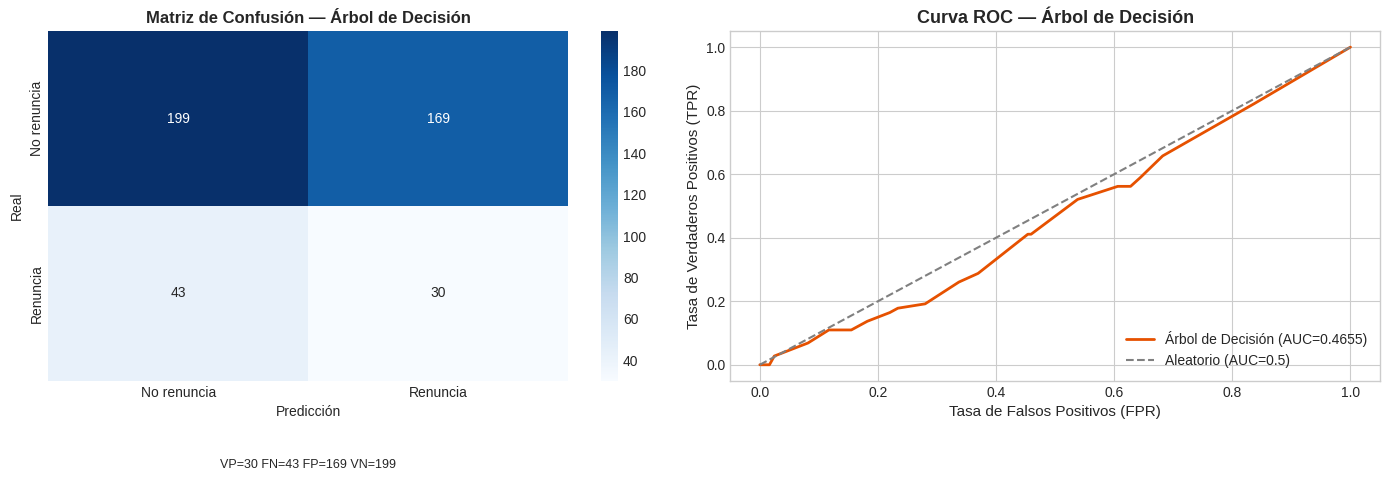


INTERPRETACIÓN:
 Falsos Negativos (FN): 43 → Empleados que renunciaron pero NO detectamos
 Falsos Positivos (FP): 169 → Empleados que NO renunciarán pero marcamos como riesgo


In [ ]:
# ============================================================
# PASO 6 — Evaluación del modelo
# ============================================================
# Calcular métricas
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)
auc = roc_auc_score(y_test, y_prob_test)

print('=' * 55)
print('ÁRBOL DE DECISIÓN — MÉTRICAS EN TEST SET')
print('=' * 55)
print(f'Accuracy: {acc:.4f} → Proporción de predicciones correctas')
print(f'Precision: {prec:.4f} → De los que predijimos "Renuncia", ¿cuántos realmente renunciaron?')
print(f'Recall: {rec:.4f} → De los que realmente renunciaron, ¿cuántos detectamos?')
print(f'F1-score: {f1:.4f} → Media armónica entre Precision y Recall')
print(f'ROC-AUC: {auc:.4f} → Capacidad discriminativa global del modelo')
print()

# Reporte completo
print('REPORTE COMPLETO DE CLASIFICACIÓN:')
print(classification_report(y_test, y_pred_test,
                            target_names=['No renuncia (0)', 'Renuncia (1)'],
                            zero_division=0))

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No renuncia', 'Renuncia'],
            yticklabels=['No renuncia', 'Renuncia'])
axes[0].set_title('Matriz de Confusión — Árbol de Decisión', fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Anotaciones interpretativas
axes[0].text(0.5, -0.25, f'VP={cm[1,1]} FN={cm[1,0]} FP={cm[0,1]} VN={cm[0,0]}',
             ha='center', transform=axes[0].transAxes, fontsize=9)

# Gráfico 2: Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, color='#E65100', lw=2, label=f'Árbol de Decisión (AUC={auc:.4f})')
axes[1].plot([0,1], [0,1], color='gray', linestyle='--', label='Aleatorio (AUC=0.5)')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC — Árbol de Decisión', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Resumen interpretativo
print('\nINTERPRETACIÓN:')
print(f' Falsos Negativos (FN): {cm[1,0]} → Empleados que renunciaron pero NO detectamos')
print(f' Falsos Positivos (FP): {cm[0,1]} → Empleados que NO renunciarán pero marcamos como riesgo')

### ✏️ Pregunta 6
**Analiza la matriz de confusión: ¿Cuántos empleados que sí renunciaron NO fueron detectados por el modelo (Falsos Negativos)? ¿Es más costoso para la empresa un Falso Negativo o un Falso Positivo en este contexto? Justifica con un argumento de negocio.**

**Respuesta:**  
La matriz de confusión muestra **43 Falsos Negativos (FN)**. Esto significa que **43 empleados que realmente renunciaron no fueron detectados por el modelo**.

En este contexto, un **Falso Negativo** suele ser más costoso para la empresa, porque significa que RRHH no identifica a tiempo a una persona en riesgo de renuncia. Si ese empleado se va, la empresa puede perder conocimiento, productividad y además asumir costos de reemplazo, selección, capacitación y adaptación de un nuevo trabajador.

Un **Falso Positivo** también tiene costo, porque se podría invertir tiempo en un empleado que no iba a renunciar. Sin embargo, ese costo suele ser menor que perder a un colaborador valioso sin haber tomado acciones preventivas.

**Interpretación:**  
El modelo todavía deja escapar varios casos reales de renuncia. Para un sistema de alerta temprana, sería importante mejorar el Recall, porque detectar a tiempo a los empleados en riesgo es más valioso para la empresa.

## Paso 7: Análisis de Overfitting - Efecto de la profundidad

Se entrenan varios árboles con distintas profundidades para comparar el rendimiento en entrenamiento y prueba.

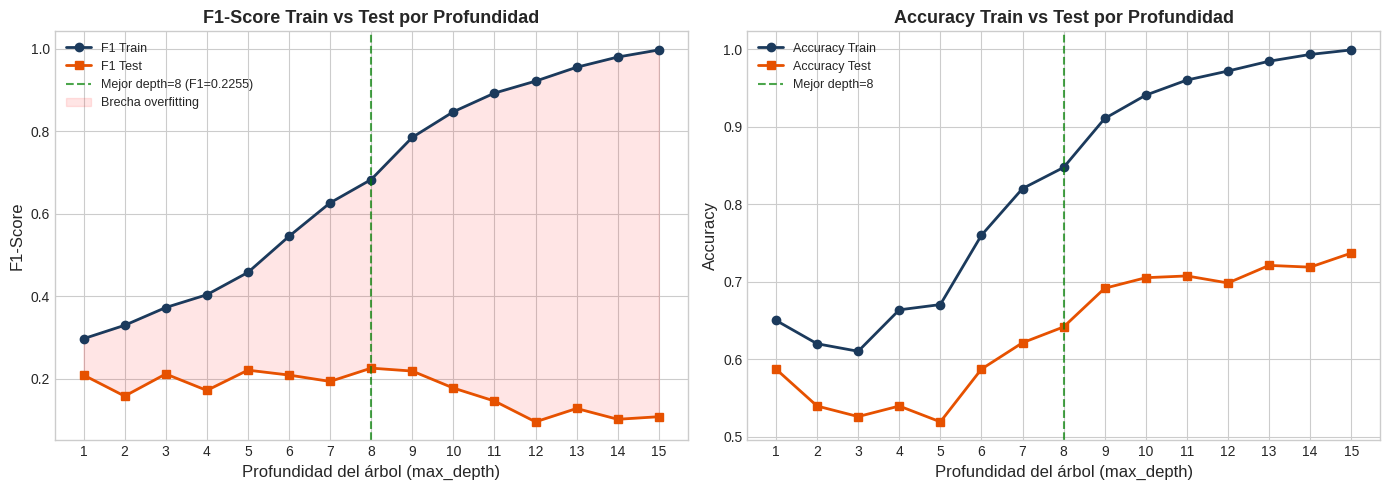


RESUMEN POR PROFUNDIDAD:
Depth      F1 Train    F1 Test   Diferencia
---------------------------------------------
1            0.2969     0.2087       0.0882
2            0.3293     0.1577       0.1717
3            0.3725     0.2113       0.1611
4            0.4034     0.1714       0.2320
5            0.4576     0.2206       0.2370
6            0.5451     0.2087       0.3364
7            0.6263     0.1932       0.4330
8            0.6828     0.2255       0.4573 ← ÓPTIMO
9            0.7850     0.2184       0.5667
10           0.8471     0.1772       0.6699
11           0.8924     0.1457       0.7467
12           0.9214     0.0952       0.8262
13           0.9551     0.1277       0.8274
14           0.9798     0.1014       0.8784
15           0.9971     0.1077       0.8894

✓ Mejor profundidad: 8 (F1 Test = 0.2255)


In [ ]:
# ============================================================
# PASO 7 — Overfitting y profundidad del árbol
# ============================================================
depths = list(range(1, 16))
f1_train_list = []
f1_test_list  = []
acc_train_list = []
acc_test_list  = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, criterion='gini',
                                    random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    ytr_pred = model.predict(X_train)
    yte_pred = model.predict(X_test)
    f1_train_list.append(f1_score(y_train, ytr_pred, zero_division=0))
    f1_test_list.append(f1_score(y_test, yte_pred, zero_division=0))
    acc_train_list.append(accuracy_score(y_train, ytr_pred))
    acc_test_list.append(accuracy_score(y_test, yte_pred))

best_depth = depths[np.argmax(f1_test_list)]
best_f1 = max(f1_test_list)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-score train vs test
axes[0].plot(depths, f1_train_list, 'o-', color='#1B3A5C', lw=2, label='F1 Train')
axes[0].plot(depths, f1_test_list, 's-', color='#E65100', lw=2, label='F1 Test')
axes[0].axvline(x=best_depth, color='green', linestyle='--', alpha=0.7,
                 label=f'Mejor depth={best_depth} (F1={best_f1:.4f})')
axes[0].fill_between(depths, f1_train_list, f1_test_list, alpha=0.1, color='red',
                      label='Brecha overfitting')
axes[0].set_xlabel('Profundidad del árbol (max_depth)', fontsize=12)
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_title('F1-Score Train vs Test por Profundidad', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xticks(depths)

# Accuracy train vs test
axes[1].plot(depths, acc_train_list, 'o-', color='#1B3A5C', lw=2, label='Accuracy Train')
axes[1].plot(depths, acc_test_list, 's-', color='#E65100', lw=2, label='Accuracy Test')
axes[1].axvline(x=best_depth, color='green', linestyle='--', alpha=0.7, label=f'Mejor depth={best_depth}')
axes[1].set_xlabel('Profundidad del árbol (max_depth)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Train vs Test por Profundidad', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(depths)

plt.tight_layout()
plt.show()

# Tabla resumen
print('\nRESUMEN POR PROFUNDIDAD:')
print(f'{"Depth":<8} {"F1 Train":>10} {"F1 Test":>10} {"Diferencia":>12}')
print('-' * 45)
for d, ft, fv in zip(depths, f1_train_list, f1_test_list):
    marker = ' ← ÓPTIMO' if d == best_depth else ''
    print(f'{d:<8} {ft:>10.4f} {fv:>10.4f} {ft-fv:>12.4f}{marker}')
print(f'\n✓ Mejor profundidad: {best_depth} (F1 Test = {best_f1:.4f})')

### ✏️ Pregunta 7
**¿En qué profundidad comienza el overfitting? ¿Cómo lo identificas en la gráfica? ¿Cuál es la profundidad óptima según el F1 en test? ¿Qué pasa con el F1 en train cuando la profundidad aumenta mucho?**

**Respuesta:**  
El overfitting empieza a notarse aproximadamente desde profundidades medias, especialmente a partir de **max_depth = 5 o 6**, porque el F1 de entrenamiento sigue subiendo, pero el F1 de prueba no mejora de la misma forma e incluso baja en varias profundidades.

En la gráfica se identifica porque aparece una brecha cada vez más grande entre la curva de **F1 Train** y la curva de **F1 Test**. Esto significa que el árbol aprende mejor los datos de entrenamiento, pero no generaliza bien con datos nuevos.

Según el resultado del laboratorio, la profundidad óptima es **max_depth = 8**, porque obtiene el mejor **F1 Test = 0.2255**. Cuando la profundidad aumenta demasiado, el F1 en train sube bastante, incluso casi llega a 1.0, pero eso indica memorización y no necesariamente mejor desempeño real.

**Interpretación:**  
Un árbol más profundo no siempre es mejor. Si crece demasiado, puede aprender detalles muy específicos del entrenamiento y perder capacidad para predecir correctamente nuevos empleados.

## Paso 8: Importancia de variables

Se reentrena el árbol con la profundidad óptima y se revisa qué variables aportaron más a la predicción.

TOP 15 VARIABLES — IMPORTANCIA EN EL ÁRBOL DE DECISIÓN
 1. Age                            0.1777  ███████████████████████████████████
 2. MonthlyIncome                  0.1412  ████████████████████████████
 3. YearsSinceLastPromotion        0.1078  █████████████████████
 4. NumCompaniesWorked             0.0952  ███████████████████
 5. DistanceFromHome               0.0822  ████████████████
 6. TrainingTimesLastYear          0.0792  ███████████████
 7. YearsInCurrentRole             0.0564  ███████████
 8. JobRole                        0.0469  █████████
 9. Education                      0.0432  ████████
10. YearsAtCompany                 0.0431  ████████
11. TotalWorkingYears              0.0408  ████████
12. Department                     0.0330  ██████
13. JobSatisfaction                0.0273  █████
14. WorkLifeBalance                0.0147  ██
15. EnvironmentSatisfaction        0.0113  ██

Variables con importancia > 0: 15
Variables sin uso en el árbol: 2


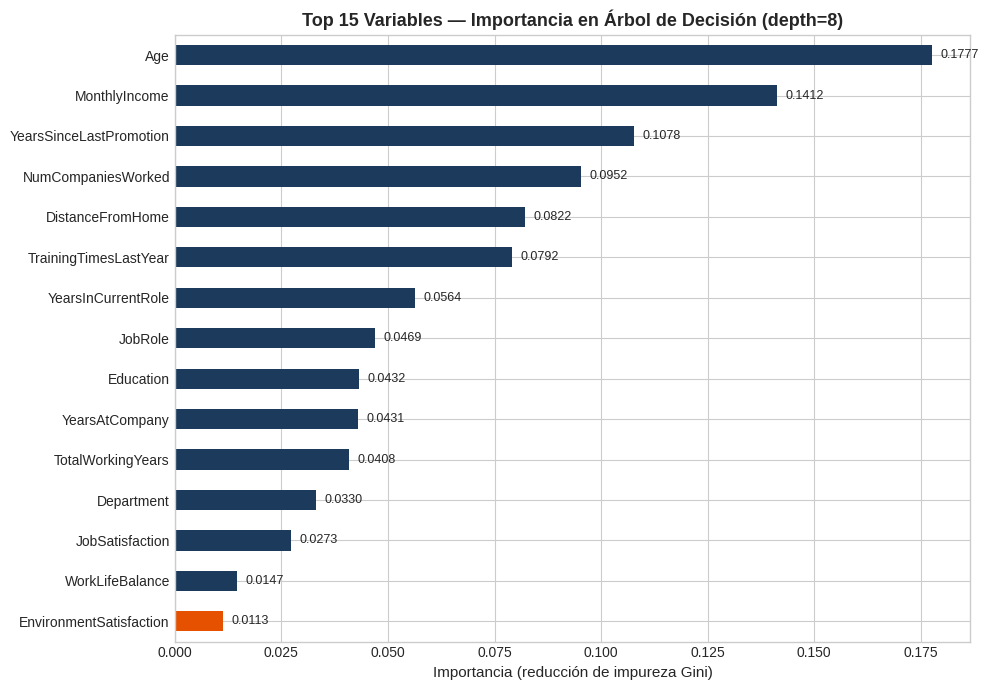

In [ ]:
# ============================================================
# PASO 8 — Importancia de variables
# ============================================================
# Reentrenar con la profundidad óptima
dt_best = DecisionTreeClassifier(
    max_depth=best_depth, criterion='gini',
    random_state=42, class_weight='balanced'
)
dt_best.fit(X_train, y_train)

# Extraer importancias
importances = pd.Series(dt_best.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

# Mostrar top 15 variables
top15 = importances.head(15)
print('TOP 15 VARIABLES — IMPORTANCIA EN EL ÁRBOL DE DECISIÓN')
print('=' * 55)
for i, (var, imp) in enumerate(top15.items(), 1):
    bar = '█' * int(imp * 200)
    print(f'{i:>2}. {var:<30} {imp:.4f}  {bar}')

print(f'\nVariables con importancia > 0: {(importances > 0).sum()}')
print(f'Variables sin uso en el árbol: {(importances == 0).sum()}')

# Visualización
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E65100' if imp == top15.max() else '#1B3A5C' for imp in top15.values]
top15.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title(f'Top 15 Variables — Importancia en Árbol de Decisión (depth={best_depth})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza Gini)', fontsize=11)
ax.invert_yaxis()

# Etiquetas de valor
for i, v in enumerate(top15.values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### ✏️ Pregunta 8
**¿Cuáles son las 3 variables más importantes en el modelo? ¿Tienen sentido desde la perspectiva de Recursos Humanos? ¿Qué variables resultan sorprendentes o contra-intuitivas? ¿Qué acciones concretas podría tomar el departamento de RRHH basándose en este análisis?**

**Respuesta:**  
Las 3 variables más importantes del modelo son **Age**, **MonthlyIncome** y **YearsSinceLastPromotion**. Desde la perspectiva de Recursos Humanos, sí tienen sentido porque la edad puede relacionarse con etapa profesional, estabilidad o búsqueda de nuevas oportunidades; el ingreso mensual puede influir en la satisfacción y permanencia; y los años desde la última promoción pueden reflejar estancamiento laboral.

Una variable que puede resultar interesante o algo contra-intuitiva es **Age**, porque no siempre se piensa como el primer factor de rotación. Sin embargo, puede estar capturando diferencias entre empleados jóvenes, con mayor movilidad laboral, y empleados con más estabilidad.

Con base en este análisis, RRHH podría revisar planes de carrera, evaluar ajustes salariales, identificar empleados que llevan mucho tiempo sin promoción y crear programas de retención personalizados. También podría reforzar conversaciones de desarrollo profesional con empleados que muestran señales de estancamiento.

**Interpretación natural:**  
El modelo sugiere que la rotación no depende de una sola causa, sino de una combinación de edad, salario, historial de promociones y trayectoria laboral dentro de la empresa.

### ✏️ Pregunta 9
**Si “OverTime” y “MonthlyIncome” aparecen entre las variables más importantes, ¿qué acciones podría tomar el departamento de RRHH para reducir la rotación?**

**Respuesta:**  
Si **OverTime** y **MonthlyIncome** aparecen como variables importantes, RRHH debería revisar la carga laboral y la compensación de los empleados. En el caso de **OverTime**, se podrían analizar áreas o puestos con exceso de horas extra, redistribuir tareas, contratar apoyo adicional o implementar políticas de equilibrio vida-trabajo.

En el caso de **MonthlyIncome**, RRHH podría revisar si los salarios son competitivos frente al mercado, identificar brechas internas y ofrecer planes de mejora salarial, bonos o beneficios no monetarios. Estas acciones pueden ayudar a reducir la sensación de desgaste o poca valoración, que muchas veces influye en la decisión de renunciar.

**Interpretación:**  
Si un empleado trabaja demasiado y además siente que su ingreso no compensa el esfuerzo, el riesgo de salida puede aumentar. Por eso, RRHH debe mirar juntas la carga laboral y la compensación.

---
# ACTIVIDAD 3: Caso de Estudio — Reducción de Rotación Laboral

**Contexto:** Una empresa de tecnología con 1,470 empleados desea implementar un sistema de alerta temprana para identificar empleados con alta probabilidad de renunciar. El costo de reemplazar un empleado se estima en 6 meses de su salario. El modelo de Árbol de Decisión será la base del sistema.

Responde cada pregunta en una celda de texto (Markdown) a continuación.

---

**A. ¿Qué factores influyen más en la renuncia según el modelo? ¿Coinciden con lo que esperarías intuitivamente como profesional de RRHH?**

**Respuesta:**  
Según el modelo, los factores que más influyen en la renuncia son **Age**, **MonthlyIncome**, **YearsSinceLastPromotion**, **NumCompaniesWorked** y **DistanceFromHome**. En general, sí coinciden con lo que se esperaría desde Recursos Humanos, porque están relacionados con estabilidad laboral, compensación, crecimiento profesional, experiencia previa y comodidad en el traslado.

Intuitivamente, un empleado con bajo ingreso, mucho tiempo sin promoción o antecedentes de cambios frecuentes de empresa puede tener mayor probabilidad de buscar nuevas oportunidades. Por eso, estos factores son útiles para construir alertas tempranas y tomar acciones preventivas.

---

**B. ¿Qué tipo de error sería más costoso para la empresa: un Falso Positivo (alarmar a un empleado que no renunciaría) o un Falso Negativo (no detectar a uno que sí renunciará)? Argumenta en términos económicos.**

**Respuesta:**  
El error más costoso sería un **Falso Negativo**, porque significa no detectar a un empleado que realmente terminará renunciando. Si la empresa no actúa a tiempo, puede perder talento, conocimiento interno y productividad. Además, reemplazar a un empleado cuesta aproximadamente **6 meses de su salario**, considerando reclutamiento, selección, capacitación y adaptación.

Un Falso Positivo también tiene costo, porque RRHH podría invertir tiempo en un trabajador que no iba a renunciar. Sin embargo, normalmente ese costo es menor que perder a un empleado clave. Por eso, en este caso conviene priorizar mejorar el **Recall** para detectar más renuncias reales.

---

**C. ¿Qué acciones concretas podría tomar el área de Recursos Humanos para los empleados identificados como "alto riesgo de renuncia"?**

**Respuesta:**  
RRHH podría realizar entrevistas de permanencia para conocer las razones de insatisfacción antes de que el empleado renuncie. También podría revisar oportunidades de promoción, planes de carrera, ajustes salariales, beneficios, carga laboral y equilibrio vida-trabajo.

Otra acción concreta sería crear un programa de seguimiento para empleados con señales de riesgo, priorizando a quienes tienen mucho tiempo sin promoción, ingresos bajos frente al mercado o alta carga de trabajo. La idea no sería presionar al empleado, sino ofrecer apoyo y soluciones reales.

---

**D. ¿Cómo usarías este modelo de manera responsable y ética en una empresa? ¿Qué riesgos de discriminación podrían surgir?**

**Respuesta:**  
Usaría este modelo como una herramienta de apoyo para RRHH, no como una decisión automática. El modelo debería ayudar a priorizar conversaciones y acciones preventivas, pero la decisión final siempre debe incluir criterio humano y revisión del contexto.

También se debe cuidar que variables como edad, área, rol o historial laboral no generen discriminación indirecta. Por ejemplo, no sería ético tratar peor a un empleado solo porque el modelo lo marca como riesgo. El uso correcto sería brindar más apoyo, oportunidades y acompañamiento, no castigos ni exclusiones.

Además, la empresa debería proteger la privacidad de los datos, explicar cómo se usa el modelo y monitorear si las predicciones afectan injustamente a ciertos grupos.

---

**E. ¿Qué mejoras propondrías para una segunda versión del modelo? (considera: más datos, otras variables, otros algoritmos, validación cruzada)**

**Respuesta:**  
Para una segunda versión, propondría incorporar más variables relacionadas con clima laboral, evaluaciones de desempeño, historial de promociones, ausentismo, participación en capacitaciones, encuestas de satisfacción y cambios recientes en el equipo o jefe directo.

También probaría otros algoritmos como Random Forest, Gradient Boosting o XGBoost, porque podrían captar patrones más complejos que un solo árbol. Además, aplicaría validación cruzada para tener una evaluación más estable y no depender de una sola división train/test.

Otra mejora importante sería ajustar el umbral de decisión según el objetivo de negocio. Si RRHH quiere detectar más empleados en riesgo, se podría priorizar Recall, aunque eso aumente algunos falsos positivos.


# Conclusiones

**Conclusión 1:**  
El laboratorio permitió aplicar un Árbol de Decisión para un problema real de clasificación en Recursos Humanos, donde la variable objetivo fue predecir si un empleado renunciará o no.

**Conclusión 2:**  
El dataset está desbalanceado, ya que solo alrededor del 16.5% de empleados renunció. Por eso, el Accuracy no es suficiente para evaluar el modelo; se deben revisar métricas como Recall, Precision, F1-score y la matriz de confusión.

**Conclusión 3:**  
La profundidad del árbol influye bastante en el rendimiento. A mayor profundidad, el modelo puede mejorar en entrenamiento, pero también aumenta el riesgo de overfitting. Por eso, controlar `max_depth` y analizar el F1 en test es clave para elegir un modelo más confiable.

**Conclusión 4:**  
Las variables más importantes, como edad, ingreso mensual y años desde la última promoción, brindan información accionable para RRHH. El modelo no debe usarse para castigar empleados, sino para prevenir la rotación mediante acciones éticas y personalizadas.

# Bibliografía

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3a ed.). O'Reilly.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer.
- Gironés Roig, J., Casado Vara, R., Minguillón Alfonso, J., & Caihuelas Quiles, R. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC.
- Mitchell, T. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn Developers. (2024). *DecisionTreeClassifier documentation*.